# Head Pose Estimation Benchmark — MediaPipe + PnP Algorithm (478-Point)

This notebook evaluates head pose estimation using **MediaPipe FaceLandmarker** combined with OpenCV's **solvePnP** algorithm. It is directly inspired by the MTCNN + PnP approach in Notebook 1, but replaces the 6-point landmark set with the full **478-point MediaPipe canonical face model**, making it a substantially more robust implementation of the same underlying geometric principle.

**Key differences from Notebook 1 (MTCNN + PnP):**
- 478 landmarks vs 6 estimated points — fully overdetermined PnP system
- `SOLVEPNP_SQPNP` solver (designed for large overdetermined sets) vs `SOLVEPNP_ITERATIVE`
- Canonical 3D face model loaded from MediaPipe's `.obj` file vs a generic 6-point approximation
- `focal_length = image_width` approximation vs 60° FOV estimate
- Y-axis flipped on 2D landmarks to match the canonical model's coordinate convention (positive Y = up)
- No chin approximation needed — chin is a directly detected landmark

**Setup:** Requires the `face_landmarker.task` model file and `face_model_with_iris.obj` canonical model, both available from the MediaPipe model repository. Place them in the notebook's working directory before running.

**Dataset:** FEI Face Database — 200 subjects × 11 pose images ranging from -90° to +90° yaw.

> **Note:** The canonical 3D face model ("face_model_with_iris.obj") was downloaded from the official MediaPipe source: https://github.com/google-ai-edge/mediapipe/tree/master/mediapipe/modules/face_geometry


## 1. Imports & Environment Setup

Imports the core libraries used throughout this notebook:
- `mediapipe` — FaceLandmarker task for 478-point landmark detection including iris landmarks
- `cv2` — PnP solving, rotation vector decomposition, and image loading
- `numpy`, `math` — landmark array handling, matrix operations, and angle conversion
- `scipy.stats.trim_mean`, `seaborn`, `matplotlib` — evaluation statistics and distribution plotting
- `tqdm` — progress tracking across the full dataset

The MediaPipe `FaceLandmarkerOptions` are configured with very low confidence thresholds (`min_face_presence_confidence=0.01`) to maximise detection rate on the full FEI dataset, including challenging near-profile images. `output_facial_transformation_matrixes=True` is enabled though the transformation matrix is not used in this notebook — it is used in Notebook 6.

In [1]:
import mediapipe as mp
import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
from collections import defaultdict
from tqdm import tqdm 
from scipy.stats import trim_mean
import matplotlib.pyplot as plt
import seaborn as sns
import os
import math
import numpy as np
import time

In [2]:
model_path = 'face_landmarker.task'
dataset_path = "/home/sawaiz/Documents/fyp phase 3/landmark_analysis/dataset/fei dataset"

## 2. Single Image Detection Test

A sanity check to verify that the MediaPipe FaceLandmarker correctly detects landmarks and returns results before running the full dataset pipeline. Selected landmark indices (left eye: 468, right eye: 473, nose: 1, chin: 175, mouth left: 61, mouth right: 291) are printed with their pixel coordinates and plotted on the image for visual verification.

Note that landmarks 468–477 are iris landmarks added by MediaPipe beyond the standard 468-point face mesh — these require the `face_model_with_iris.obj` canonical model which includes the corresponding 3D positions.

In [3]:

BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=model_path),
    running_mode=VisionRunningMode.IMAGE,
    min_face_presence_confidence=0.01,
    min_tracking_confidence=0.01,
    output_face_blendshapes=True,
    output_facial_transformation_matrixes=True
)

In [4]:
# Load the input image from an image file.
img_path = '1-10.jpg'
mp_image = mp.Image.create_from_file(img_path)
frame = cv2.imread(img_path)

with FaceLandmarker.create_from_options(options) as landmarker:
  # The landmarker is initialized. Use it here.
  face_landmarker_result = landmarker.detect(mp_image)
face_landmarker_result.face_landmarks

W0000 00:00:1774494137.635657 2281816 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1774494137.651520 2281817 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774494137.665564 2281820 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


[[NormalizedLandmark(x=0.8113844394683838, y=0.7846792936325073, z=-0.020894935354590416, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.8508551120758057, y=0.7030293941497803, z=-0.03774595260620117, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.8078340291976929, y=0.7321481704711914, z=-0.021807914599776268, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.8208822011947632, y=0.6403599977493286, z=-0.04424605146050453, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.854902982711792, y=0.6817896366119385, z=-0.041366226971149445, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.8440415859222412, y=0.6571856141090393, z=-0.038705211132764816, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.8027963638305664, y=0.588636577129364, z=-0.018503105267882347, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.7028999328613281, y=0.5905065536499023, z

left_eye: (326, 219)
right_eye: (349, 212)
nose: (382, 265)
chin: (341, 355)
mouth_right: (348, 304)
mouth_left: (332, 310)


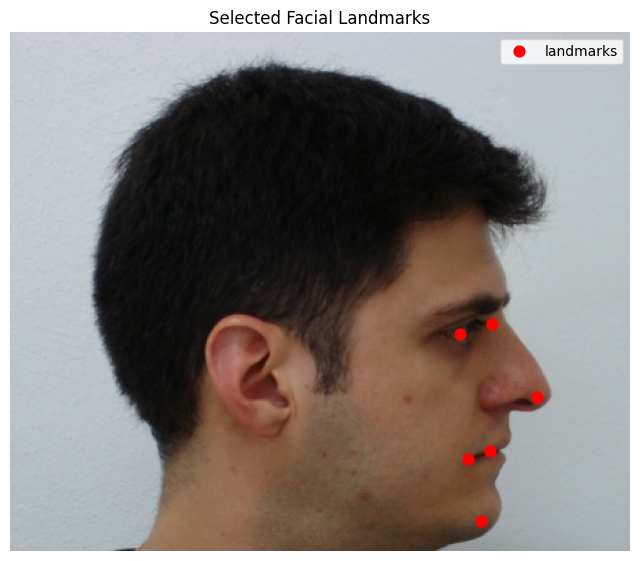

In [5]:
# mouth_center_indices = [14, 13]
left_eye = [468]
right_eye = [473]
nose_indices = [1]
chin = [175]
mouth_left = [291]
mouth_right = [61]
face_boundary_indices = []

# Mapping from index to landmark name for printing
landmark_names = {
    468: "left_eye",
    473: "right_eye",
    1: "nose",
    175: "chin",
    61: "mouth_left",
    291: "mouth_right",
    # Add more names here if you add more indices
}

# Convert mp.Image to numpy array
image_np = mp_image.numpy_view()

# Collect all the indices for the required points
all_indices = left_eye + right_eye + nose_indices + chin + mouth_left + mouth_right + face_boundary_indices
# Extract the first (and assumed only) face's landmarks
landmarks = face_landmarker_result.face_landmarks[0]

h, w, _ = image_np.shape

# Get (x, y) points for each index, converting normalized coords to pixel coords
points = []
for idx in all_indices:
    lm = landmarks[idx]
    px = int(lm.x * w)
    py = int(lm.y * h)
    name = landmark_names.get(idx, f'index_{idx}')
    print(f"{name}: ({px}, {py})")
    points.append((px, py))

# Plot the image and selected facial points
plt.figure(figsize=(8,8))
plt.imshow(image_np)
xs, ys = zip(*points)

plt.scatter(xs, ys, c='red', s=60, marker='o')
plt.axis('off')
plt.title('Selected Facial Landmarks')
plt.legend(['landmarks', 'mouth_center'])
plt.show()

## 3. Canonical 3D Model & Pose Estimation Functions

#### `load_canonical_model()`
Parses MediaPipe's `face_model_with_iris.obj` file to extract 478 3D vertex positions in canonical face space. These serve as the `model_points` in solvePnP — each index directly corresponds to the same-indexed MediaPipe landmark, providing a true 1-to-1 2D-to-3D correspondence for all 478 points.

#### `extract_and_unnormalize()`
Converts all 478 normalised MediaPipe landmark coordinates (range 0–1) to pixel space. Critically, the Y-axis is **flipped** (`y = (1 - y_norm) * height`) to match the canonical model's convention where positive Y points upward — without this flip, the PnP solver would receive geometrically inconsistent correspondences and produce incorrect rotation estimates.

#### `face_orientation()`
Implements the full PnP-based pose estimation pipeline:
1. Constructs a synthetic pinhole camera matrix using `focal_length = image_width` — a well-established empirical approximation
2. Runs `cv2.solvePnP` with `SOLVEPNP_SQPNP`, the recommended solver for large overdetermined point sets
3. Converts the rotation vector to Euler angles via `cv2.Rodrigues` and `cv2.decomposeProjectionMatrix`
4. Normalises all angles to the [-90°, 90°] range via `asin(sin(x))`

#### `get_rpy()`
Top-level convenience function that chains image loading, landmark detection, unnormalisation, and pose estimation into a single call returning `(roll, pitch, yaw)` or `None` if detection fails.

In [6]:
def load_canonical_model(obj_path):
    """
    Returns an (N, 3) array of 3D points in MediaPipe canonical face space.
    Indices match MediaPipe's 478-point landmark indices directly.
    Requires face_model_with_iris.obj (478 points, includes iris 468-477).
    """
    vertices = []
    with open(obj_path, 'r') as f:
        for line in f:
            if line.startswith('v '):
                _, x, y, z = line.split()
                vertices.append((float(x), float(y), float(z)))
    return np.array(vertices)  # shape: (478, 3)
 
 
canonical_model = load_canonical_model("face_model_with_iris.obj")
 
 
def face_orientation(frame, landmarks_unnorm):
    """
    Estimates face orientation using all 478 MediaPipe landmarks via solvePnP.
 
    Parameters
    ----------
    frame           : np.ndarray  — image (used only for shape / camera matrix)
    landmarks_unnorm: np.ndarray  — shape (478, 2), unnormalised pixel coords,
                                    Y already flipped to match canonical model.
 
    Returns
    -------
    (roll, pitch, yaw) in degrees, or None if solvePnP fails.
    """
    size = frame.shape  # (height, width, channels)
 
    image_points = landmarks_unnorm.astype("double")   # (478, 2)
    model_points = canonical_model.astype("double")    # (478, 3)
 
    # Camera intrinsics estimated from image size.
    # focal_length = image_width is a reliable empirical approximation.
    image_width  = size[1]
    image_height = size[0]
    center = (image_width / 2.0, image_height / 2.0)
    focal_length = image_width
    camera_matrix = np.array([
        [focal_length, 0,            center[0]],
        [0,            focal_length, center[1]],
        [0,            0,            1         ]
    ], dtype="double")
 
    dist_coeffs = np.zeros((4, 1))  # Assuming no lens distortion
 
    # SOLVEPNP_SQPNP is the most robust solver for large over-determined sets.
    success, rotation_vector, translation_vector = cv2.solvePnP(
        model_points, image_points, camera_matrix, dist_coeffs,
        flags=cv2.SOLVEPNP_SQPNP
    )
 
    if not success:
        return None
 
    # Convert rotation vector to Euler angles.
    rvec_matrix = cv2.Rodrigues(rotation_vector)[0]
    proj_matrix = np.hstack((rvec_matrix, translation_vector))
    eulerAngles = cv2.decomposeProjectionMatrix(proj_matrix)[6]
 
    eulerAngles = [
        float(e[0]) if isinstance(e, (np.ndarray, np.generic)) else float(e)
        for e in eulerAngles
    ]
    pitch, yaw, roll = [math.radians(a) for a in eulerAngles]
 
    pitch = math.degrees(math.asin(math.sin(pitch)))
    roll  = -math.degrees(math.asin(math.sin(roll)))
    yaw   = math.degrees(math.asin(math.sin(yaw)))
 
    return (roll, pitch, yaw)
 
 
def extract_and_unnormalize(landmarks, image_width, image_height):
    """
    Converts all 478 normalised MediaPipe landmarks to unnormalised pixel
    coordinates with Y flipped to match the canonical model's convention
    (positive Y = up).
 
    Parameters
    ----------
    landmarks     : MediaPipe face landmark list (478 items)
    image_width   : int
    image_height  : int
 
    Returns
    -------
    np.ndarray of shape (478, 2), dtype float64
    """
    points = np.array(
        [(lm.x, lm.y) for lm in landmarks],
        dtype="double"
    )  # shape (478, 2), normalised
 
    points[:, 0] = np.round(points[:, 0] * image_width)           # x: left -> right
    points[:, 1] = np.round((1.0 - points[:, 1]) * image_height)  # y: flip to match model
 
    return points  # shape (478, 2), pixel coords
 
 
def get_rpy(image_path):
    """
    Returns (roll, pitch, yaw) in degrees for the first detected face,
    or None if no face is detected or solvePnP fails.
 
    Assumes `mp`, `FaceLandmarker`, and `options` are defined in the
    enclosing scope (your existing MediaPipe setup).
    """
    mp_image = mp.Image.create_from_file(image_path)
 
    with FaceLandmarker.create_from_options(options) as landmarker:
        face_landmarker_result = landmarker.detect(mp_image)
 
    landmarks = face_landmarker_result.face_landmarks
 
    if not landmarks:
        return None
 
    image = cv2.imread(image_path)
    image_height, image_width = image.shape[:2]
 
    # Convert all 478 landmarks to unnormalised pixel coords (Y flipped).
    landmarks_unnorm = extract_and_unnormalize(
        landmarks[0], image_width, image_height
    )
 
    return face_orientation(image, landmarks_unnorm)

## 4. Full Dataset Processing

Iterates over all 200 subjects and 11 pose positions, running the full MediaPipe + PnP pipeline on each image. Results are stored in per-position angle lists and a per-person dictionary for evaluation.

Note that unlike the other notebooks, this approach does not achieve n=200 at all positions — **n=187 at -90°** and **n=192 at +90°** indicate that MediaPipe fails to detect faces in 13 and 8 images respectively at the most extreme profile angles. This is expected behaviour: at true ±90° profile views, MediaPipe's face detector struggles as the face becomes a near-featureless silhouette. All mid-range positions achieve full n=200 detection.

In [7]:
# Define the ordered positions with their corresponding position codes
ordered_positions = ['-90', '-75', '-60', '-45', '-30', '30', '45', '60', '75', '90', '0']
position_map = {f"{i+1:02d}": pos_label for i, pos_label in enumerate(ordered_positions)}

# Dicts to accumulate roll, pitch, and yaw angles for each position label
yaw_angles_by_position = defaultdict(list)
pitch_angles_by_position = defaultdict(list)
roll_angles_by_position = defaultdict(list)

person_ids = list(range(1, 201))  # assuming 1 to 200
positions = list(range(1, 12))    # image positions 01 to 11

# Store per-person ALL pose angles for every position
person_pose = defaultdict(dict) # person_pose[person_id][position_label] = (roll, pitch, yaw)

num_images_processed = 0
start_time = time.time()

for person_id in tqdm(person_ids, desc="Processing Persons"):
    person_prefix = str(person_id)
    for pos_idx, pos in enumerate(positions):
        pos_str = f"{pos:02d}"  # zero-padded position index
        pos_label = ordered_positions[pos_idx]
        img_name = f"{person_prefix}-{pos_str}.jpg"
        img_path = os.path.join(dataset_path, img_name)
        if not os.path.isfile(img_path):
            img_name = f"{person_prefix}-{pos_str}.JPG"
            img_path = os.path.join(dataset_path, img_name)
        
        if not os.path.isfile(img_path):
            continue  # skip if file doesn't exist

        result = get_rpy(img_path)
        if result:
            roll, pitch, yaw = result

            roll_angles_by_position[pos_label].append(roll)
            pitch_angles_by_position[pos_label].append(pitch)
            yaw_angles_by_position[pos_label].append(yaw)
            person_pose[person_id][pos_label] = (roll, pitch, yaw)
            num_images_processed += 1

end_time = time.time()
if num_images_processed > 0:
    avg_time_per_image = (end_time - start_time) / num_images_processed
    print(f"\nAverage time taken to process 1 image: {avg_time_per_image:.4f} seconds")
else:
    print("\nNo images processed, cannot compute average time.")

Processing Persons:   0%|          | 0/200 [00:00<?, ?it/s]

W0000 00:00:1774494137.944157 2281836 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1774494137.951970 2281844 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774494137.970847 2281837 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774494137.996109 2281849 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1774494138.002374 2281852 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774494138.013826 2281854 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:


Average time taken to process 1 image: 0.0304 seconds


## 5. Evaluation Metric 1 — Monotonic Yaw Increase Check

For a head pose estimator to be considered reliable, predicted yaw values should **strictly increase** as the head rotates from -90° to +90°. Since the FEI dataset captures subjects at physically ordered pose angles, any non-increasing transition indicates the model failed to track the angular change between those two positions.

**Metric:** Count of broken (non-increasing) transitions out of 2000 possible (200 persons × 10 consecutive steps).

> **Note:** The frontal 0° position is excluded from the monotonicity sequence in this notebook (same convention as Notebook 4), giving 10 positions and 9 steps per person.

### Result

The MediaPipe + PnP approach achieves **42 broken transitions out of 2000**, affecting **37 out of 200 subjects** — the third best monotonicity result in the benchmark after L2CS (12) and LivePortrait (39). Compared to the MTCNN + PnP approach in Notebook 1 (265 breaks, 157 subjects), the improvement from upgrading to 478 landmarks and the SQPNP solver is dramatic. The character of the failures is also qualitatively different: there are no catastrophic sign-flip failures, and the largest gap in the entire output is -13.16° (Person 091 at `0°→30°`). The dominant failure pattern is the **`0°→30°` transition**, which accounts for the majority of breaks — a compression zone near the frontal plane where small absolute errors can violate the ordering condition, identical in character to the LivePortrait failures. A secondary cluster appears at `-60°→-45°` with mostly tiny gaps (under 1°) that represent floating-point-level noise rather than genuine estimation errors. The `45°→60°` transition on the positive side shows a similar pattern. Notably, the extreme ±90° transitions — the most problematic region for MTCNN + PnP — produce virtually no breaks here, confirming that the 478-point overdetermined system dramatically stabilises estimation at profile angles. The missing detections at ±90° (n=187 and n=192) mean some of the hardest cases are simply excluded from the check, which slightly flatters this metric.

In [8]:
positions_order = ['-90', '-75', '-60', '-45', '-30', '0', '30', '45', '60', '75', '90']
breaks_info = []  # (person_id, break_index, (previous_yaw, current_yaw))
total_persons_checked = 0
total_gap_instances = 0
total_non_increasing = 0
gaps = []

# To track all gaps per person with a break
person_break_gaps = {}  # person_id -> list of gaps for that person

for person_id in sorted(person_pose.keys()):
    yaws = [person_pose[person_id][pos][2] for pos in positions_order if pos in person_pose[person_id]]
    # Only check if all 10 positions present
    if any(yaw is None for yaw in yaws):
        continue
    total_persons_checked += 1
    person_gaps = []
    for i in range(len(yaws) - 1):
        if yaws[i] >= yaws[i + 1]:
            # Record the first break: index, and values at break
            breaks_info.append((person_id, positions_order[i], yaws[i], positions_order[i+1], yaws[i+1]))
            # Calculate the gap (difference between previous_yaw and current_yaw at break)
            gap = yaws[i+1] - yaws[i]  # should be negative or zero
            gaps.append(gap)
            person_gaps.append(gap)
            total_gap_instances += 1

    if person_gaps:
        total_non_increasing += 1
        person_break_gaps[person_id] = person_gaps

if breaks_info:
    print("Persons and positions where yaw does NOT strictly increase from 01 to 10:")
    for person_id, pos1, yaw1, pos2, yaw2 in breaks_info:
        gap_this_break = yaw2 - yaw1

        print(f" Person {person_id:03d}: Break at {pos1}→{pos2} | yaw: {yaw1:.2f}° → {yaw2:.2f}° | gap: {gap_this_break:.2f}°")
    print(f"\nTotal persons with non-increasing yaw: {total_non_increasing} out of {total_persons_checked}")
    print(f"\nTotal number of non-increasing transitions detected (gap instances): {total_gap_instances} out of {total_persons_checked * (len(positions_order)-1)} possible transitions "
          f"(200 persons × 10 steps = {200*10} transitions)")

else:
    print("All persons have strictly increasing yaw from 01 to 10.")
    print(f"\nTotal persons checked: {total_persons_checked}")

Persons and positions where yaw does NOT strictly increase from 01 to 10:
 Person 002: Break at 0→30 | yaw: 1.46° → -1.22° | gap: -2.68°
 Person 010: Break at 45→60 | yaw: 34.71° → 34.02° | gap: -0.69°
 Person 011: Break at -60→-45 | yaw: -24.26° → -24.51° | gap: -0.25°
 Person 011: Break at 0→30 | yaw: 3.98° → 0.82° | gap: -3.16°
 Person 011: Break at 30→45 | yaw: 0.82° → -3.11° | gap: -3.93°
 Person 027: Break at 0→30 | yaw: 5.55° → 2.58° | gap: -2.97°
 Person 030: Break at 0→30 | yaw: 5.71° → -1.60° | gap: -7.31°
 Person 032: Break at 45→60 | yaw: 33.31° → 33.02° | gap: -0.29°
 Person 033: Break at -60→-45 | yaw: -35.45° → -35.54° | gap: -0.09°
 Person 039: Break at 0→30 | yaw: -2.02° → -5.44° | gap: -3.42°
 Person 041: Break at 45→60 | yaw: 37.87° → 28.90° | gap: -8.97°
 Person 047: Break at 0→30 | yaw: 3.30° → 1.48° | gap: -1.83°
 Person 052: Break at 45→60 | yaw: 33.07° → 31.49° | gap: -1.59°
 Person 055: Break at -60→-45 | yaw: -33.51° → -34.36° | gap: -0.85°
 Person 059: Break 

## 6. Evaluation Metric 2 — Trimmed Mean Yaw, Pitch & Roll per Position

Computes the **10% trimmed mean** of predicted roll, pitch, and yaw across all detected subjects at each of the 11 ground truth positions. Note that n=187 at -90° and n=192 at +90° due to detection failures at extreme profile angles.

This metric evaluates:
1. **Calibration** — does the predicted yaw trend in the right direction and reach a plausible magnitude at each position?
2. **Stability** — do pitch and roll remain near zero across positions where they should theoretically be constant?

### Result

The trimmed mean yaw values show a strong monotonic trend across all 11 positions, with the frontal position returning 1.53° — an excellent near-zero result and the best calibration at 0° of any method with full roll/pitch/yaw output in this benchmark. At the extremes, the model predicts -68.32° at -90° and 69.94° at +90°, the closest approach to the true ±90° targets of any method in the benchmark — a direct benefit of the overdetermined 478-point PnP system. However, two significant stability concerns are visible. Pitch shows a **persistent positive bias of ~7–8°** across all mid-range positions (7.79° to 8.36° from -75° to +30°), indicating a systematic upward tilt in the PnP solution that is not related to actual head pitch — likely a consequence of the synthetic camera matrix assumption or a slight mismatch between the canonical model's coordinate frame and the FEI dataset's camera setup. This bias spikes sharply at the extremes: 17.05° at -90° and 19.10° at +90°, showing the same yaw-pitch coupling seen in Notebook 1 but at a reduced magnitude. Roll tells a more nuanced story — it stays close to zero at frontal (−1.30°) and grows symmetrically with yaw magnitude, reaching 16.83° at -90° and −20.24° at +90°. This roll-yaw coupling is a known artefact of decomposing a rotation matrix into Euler angles when the rotation approaches gimbal-lock territory near ±90° yaw, and is not unique to this method.

In [9]:
ordered_positions = ['-90', '-75', '-60', '-45', '-30', '30', '45', '60', '75', '90', '0']
avg_yaw_by_position = {}
avg_pitch_by_position = {}
avg_roll_by_position = {}

# Use a trimmed mean (e.g., trim 10% at each end)
trim_fraction = 0.1

for pos_str in tqdm(ordered_positions, desc="Calculating averages"):
    yaws = yaw_angles_by_position[pos_str]
    pitches = pitch_angles_by_position[pos_str]
    rolls = roll_angles_by_position[pos_str]
    if yaws:
        avg_yaw = trim_mean(yaws, proportiontocut=trim_fraction)
        avg_pitch = trim_mean(pitches, proportiontocut=trim_fraction) if pitches else float('nan')
        avg_roll = trim_mean(rolls, proportiontocut=trim_fraction) if rolls else float('nan')
        avg_yaw_by_position[pos_str] = avg_yaw
        avg_pitch_by_position[pos_str] = avg_pitch
        avg_roll_by_position[pos_str] = avg_roll
        print(f"Position {pos_str}: Trimmed Avg Yaw = {avg_yaw:.2f}°, Pitch = {avg_pitch:.2f}°, Roll = {avg_roll:.2f}° (n={len(yaws)})")
    else:
        print(f"Position {pos_str}: No valid faces found.")


Calculating averages: 100%|██████████| 11/11 [00:00<00:00, 1107.53it/s]

Position -90: Trimmed Avg Yaw = -68.32°, Pitch = 17.05°, Roll = 16.83° (n=187)
Position -75: Trimmed Avg Yaw = -50.49°, Pitch = 7.79°, Roll = 5.59° (n=200)
Position -60: Trimmed Avg Yaw = -37.64°, Pitch = 6.68°, Roll = 3.04° (n=200)
Position -45: Trimmed Avg Yaw = -31.40°, Pitch = 7.14°, Roll = 2.31° (n=200)
Position -30: Trimmed Avg Yaw = -15.03°, Pitch = 7.94°, Roll = 0.41° (n=200)
Position 30: Trimmed Avg Yaw = 11.34°, Pitch = 8.36°, Roll = -2.27° (n=200)
Position 45: Trimmed Avg Yaw = 29.10°, Pitch = 7.73°, Roll = -4.44° (n=200)
Position 60: Trimmed Avg Yaw = 37.60°, Pitch = 7.45°, Roll = -5.18° (n=200)
Position 75: Trimmed Avg Yaw = 47.88°, Pitch = 7.87°, Roll = -6.96° (n=200)
Position 90: Trimmed Avg Yaw = 69.94°, Pitch = 19.10°, Roll = -20.24° (n=192)
Position 0: Trimmed Avg Yaw = 1.53°, Pitch = 7.95°, Roll = -1.30° (n=200)


## 7. Evaluation Metric 3 — Yaw Distribution per Position

Plots the full distribution of predicted yaw values across all detected subjects for each of the 11 ground truth positions. Each subplot shows a histogram with a KDE overlay, along with vertical lines marking the raw mean and 10% trimmed mean.

### Result

The distribution plots reveal a method that performs strongly and consistently across the full yaw range, with a few notable characteristics. Distributions are **unimodal and well-formed** at every position, with raw mean and trimmed mean lines nearly coincident throughout — confirming the absence of the outlier clusters and sign-flip failures that plagued the MTCNN + PnP approach. Standard deviations range from 4.69° at the frontal position to 7.55° at +75°, with all positions in the 5–7° range — tighter than MTCNN + PnP but slightly wider than L2CS. The -90° distribution (n=187, std=6.09°) and +90° distribution (n=192, std=5.83°) are the narrowest of the extreme positions seen in this benchmark, and both are cleanly unimodal and centred on plausible values (-68° and +70° respectively) — a stark contrast to the collapse or bimodality seen in other methods at these angles. The frontal (0°) distribution is clean and tight (std=4.69°) and well-centred near zero. A consistent feature across all subplots is that the distributions are slightly right-skewed on the negative side and left-skewed on the positive side, reflecting mild compression that increases with angle — but without the dramatic underestimation seen in purely geometric methods. Overall the plots confirm this as the most geometrically faithful and stable PnP-based approach in the benchmark, with the 478-point overdetermined system delivering clear and measurable improvements over the 6-point MTCNN baseline.

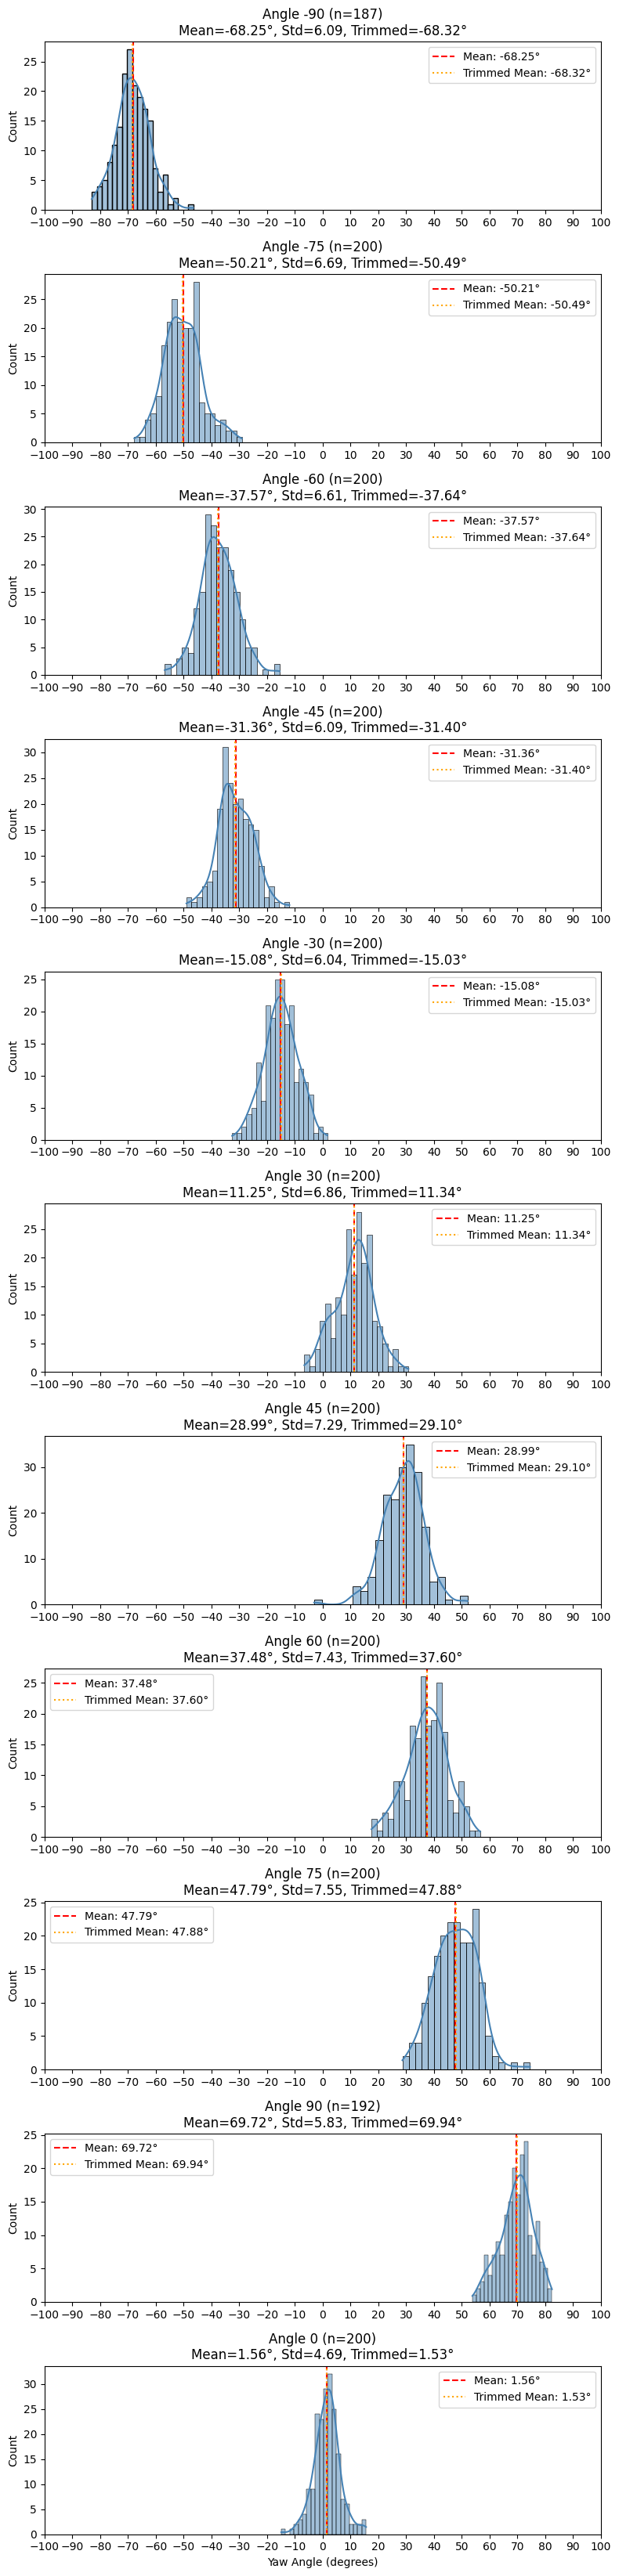

In [10]:
positions_order = ['-90', '-75', '-60', '-45', '-30', '30', '45', '60', '75', '90', '0']

# Prepare for plotting
positions = sorted(yaw_angles_by_position.keys())

fig, axes = plt.subplots(len(positions), 1, figsize=(8, 3 * len(positions)), sharex=True)

if len(positions) == 1:
    axes = [axes]  # in case only one position

for idx, pos_str in enumerate(positions_order):
    yaws = yaw_angles_by_position[pos_str]
    ax = axes[idx]
    if yaws:
        sns.histplot(yaws, bins=20, kde=True, ax=ax, color='steelblue')
        mean = np.mean(yaws)
        trimmed = trim_mean(yaws, proportiontocut=0.1)
        std = np.std(yaws)
        n = len(yaws)
        ax.axvline(mean, color='red', linestyle='--', label=f"Mean: {mean:.2f}°")
        ax.axvline(trimmed, color='orange', linestyle=':', label=f"Trimmed Mean: {trimmed:.2f}°")
        ax.set_title(f"Angle {pos_str} (n={n})\nMean={mean:.2f}°, Std={std:.2f}, Trimmed={trimmed:.2f}°")

        # Set the x-axis limits from -90 to 90 as requested
        ax.set_xlim(-100, 100)

        # Set x-axis ticks every 10 degrees
        ax.set_xticks(np.arange(-100, 101, 10))

        # Ensures y axis shows tick labels for each plot clearly
        ax.tick_params(axis='y', which='both', labelleft=True, left=True)
        ax.yaxis.set_tick_params(labelleft=True)
        ax.set_ylabel("Count")

        # Ensure x-axis and y-axis tick labels are visible and not overlapped
        ax.tick_params(axis='x', which='both', labelbottom=True, bottom=True, labelsize=10, rotation=0)
        ax.xaxis.set_tick_params(labelbottom=True)
        for label in ax.get_xticklabels():
            label.set_visible(True)
            label.set_fontsize(10)
            label.set_rotation(0)

        ax.legend()
        
    else:
        ax.set_title(f"Position {pos_str}: No valid data")
        ax.axis('off')

    # Set x-axis label for every axes (even for 'off' axes for consistency)
    ax.set_xlabel("Yaw Angle (degrees)")

# Redraw to ensure all ticks and labels are correctly applied
plt.tight_layout()
plt.show()